# Finding ground state by variational optimization of Matrix product state(MPS)

# Lecture 10

## 10.1 Finding ground states by variational optimization of MPS

### Variational ansatz (MPS):

$$|\psi\rangle = \sum_{i_1 \dots i_N} \sum_{\alpha_1 \dots \alpha_{N-1}}^D A_{\alpha_1}^{[1] i_1} A_{\alpha_1 \alpha_2}^{[2] i_2} \dots A_{\alpha_{N-1}}^{[N] i_N} |i_1 \dots i_N\rangle$$

> **Note on variables:** The elements of these tensors ($A$) act as the **variational parameters**.

### Goal:
For a given $H$, find the parameters that minimize $\langle\psi|H|\psi\rangle$ under the constraint $\langle\psi|\psi\rangle = 1$.

*(If the ground state indeed has low entanglement, i.e., Schmidt rank $\le D$ for each cut, the solution to this optimization problem will be a good approximation to the ground state.)*

$$E_g = \min_{|\psi\rangle} \frac{\langle\psi|H|\psi\rangle}{\langle\psi|\psi\rangle} \implies \min_{\text{params of } |\psi\rangle} \left( \langle\psi|H|\psi\rangle - \lambda \langle\psi|\psi\rangle \right) \quad (*)$$

Where $\lambda$ is the **Lagrange multiplier** (and $\lambda$ will be the ground state energy).

* **Highly non-linear optimization problem:** Products of $N$ parameters appear.
* But $|\psi\rangle$ is **linear** in the elements of any individual tensor $A^{[i]}$. $\implies$ The objective function $(*)$ is **quadratic** in the elements of $A^{[i]}$.

### $\rightarrow$ Do an iterative optimization!
Optimize $(*)$ with respect to each tensor one after the other, and repeat until the energy converges.

Pick individual tensor $A^{[i]} := A$

$$\min_A \left( \langle\psi|H|\psi\rangle - \lambda \langle\psi|\psi\rangle \right) = \min_A \left( \vec{A}^\dagger H_{\text{eff}} \vec{A} - \lambda \vec{A}^\dagger N \vec{A} \right)$$

*Note on the left side:* $\langle\psi|H|\psi\rangle$ is linear in $A^*_{\alpha_i \alpha_{i+1}}$ and linear in $A_{\alpha_i \alpha_{i+1}}$.  
*Note on the right side:* All elements of $A$ are written into a vector $\vec{A}$ of dimension $dD^2$.

Determine extremum with respect to $\vec{A}^\dagger$:

$$\frac{\partial}{\partial \vec{A}^\dagger} \left( \vec{A}^\dagger H_{\text{eff}} \vec{A} - \lambda \vec{A}^\dagger N \vec{A} \right) \stackrel{!}{=} 0$$

Leads to the **generalized eigenvalue problem**:

$$H_{\text{eff}} \vec{A} = \lambda N \vec{A}$$

* Can be solved by standard techniques. 
* The solution of this optimization problem is the ground state. 
* The ground state energy $\lambda_0$ is the current approximation to the ground state energy.

Do this sequentially for tensors $A^{[1]}, \dots, A^{[N]}$ and repeat.

$\implies$ This is equivalent to the **D**ensity **M**atrix **R**enormalization **G**roup (**DMRG**) algorithm (invented before MPS $\rightarrow$ formulated differently).

### How to compute $H_{\text{eff}}$ and $N$?

* They represent the expectation value of the $\hat{H}$ operator with one tensor pair $A^{[i]*}, A^{[i]}$ left un-summed.
* This results in a $dD^2 \times dD^2$ matrix (or a $d \times D \times D \times d \times D \times D$ tensor).

* $\rightarrow$ Use our tensor contraction techniques to get this efficiently.
* $\rightarrow$ $H$ is a sum of operators. Need to write it as a **Matrix Product Operator (MPO)**.

### Example: Transverse Field Ising Model

$$H = -J \sum_{i} \sigma_i^z \sigma_{i+1}^z - B \sum_{i} \sigma_i^x \quad \text{(sum of terms / operator products)}$$

### Goal: Write in the MPO form
$$H = \sum_{\alpha_1 \dots \alpha_{N-1}} W_{\alpha_1}^{[1]} \otimes W_{\alpha_1 \alpha_2}^{[2]} \dots \otimes W_{\alpha_{N-1}}^{[N]}$$

* **Tensor product level:** Product of Pauli-operators.
* $W^{[2]}_{\alpha_1 \alpha_2}$ is a $D \times D$ matrix of $d \times d$ matrices $\rightarrow$ a **rank-4 tensor**.
* *(Could also be written out with local indices: $\sum_{i_2, j_2}^d W_{\alpha_1 \alpha_2}^{[2] i_2 j_2} |i_2\rangle \langle j_2|$)*

### For the given example:

$$W^{[1]} = \begin{pmatrix} -B \sigma_1^x & -J \sigma_1^z & \mathbb{1} \end{pmatrix}$$

$$W^{[k]} = \begin{pmatrix} \mathbb{1} & 0 & 0 \\ \sigma_k^z & 0 & 0 \\ -B \sigma_k^x & -J \sigma_k^z & \mathbb{1} \end{pmatrix}$$

$$W^{[N]} = \begin{pmatrix} \mathbb{1} \\ \sigma_N^z \\ -B \sigma_N^x \end{pmatrix}$$

> **Exercise:** Verify that $\sum_{\alpha_1 \dots \alpha_{N-1}} W_{\alpha_1}^{[1]} \otimes \dots \otimes W_{\alpha_{N-1}}^{[N]} = H$.

### With this, $H_{\text{eff}}$ in diagrammatic notation is:

*(Refer to the handwritten diagram: A three-row tensor network representing the bra MPS, the MPO string $W$, and the ket MPS, with the tensors $A^{[k]}$ and $A^{[k]\dagger}$ omitted at site $k$.)*

* **6 open indices:**
  * Local physical indices: $i_k, i_k' \rightarrow$ dimension $d$
  * Virtual bond indices: $\alpha_k$ etc. $\rightarrow$ dimension $D$
* Total tensor dimension: $d \times D \times D \times d \times D \times D$ or $dD^2 \times dD^2$ *(obtained by flattening the tensors $A^{[k]}, A^{[k]\dagger}$)*.

For the normalization matrix $N$:  
$$W^{[k]} = \mathbb{1} \quad \forall k$$

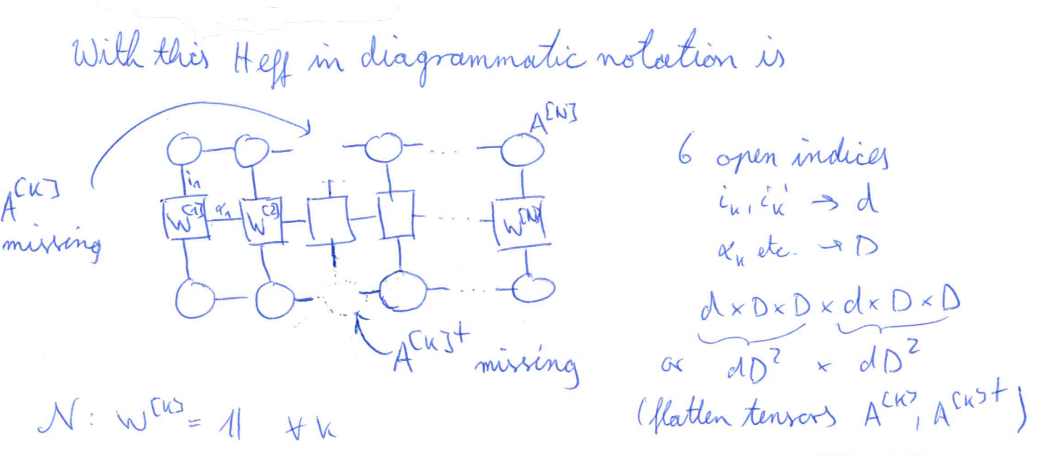

## 10.2 (Imaginary) time propagation (TEBD)

$$|g\rangle = \lim_{\tau \to \infty} \frac{e^{-\tau H} |\psi_0\rangle}{\langle\psi(\tau)|\psi(\tau)\rangle} \quad \text{(see also lecture 1+2)}$$

* $\tau$: imaginary time
* $|\psi_0\rangle$: initial guess (with $\langle\psi_0|g\rangle \neq 0$)

### How to calculate $e^{-\tau H} |\psi_0\rangle$ for an MPS?

#### Trotter-Suzuki decomposition:

$$e^{-\tau H} = \left(e^{-\delta\tau H}\right)^m \approx \left( \prod_{\langle i,j \rangle} e^{-\delta\tau h_{ij}} \right)^m$$

* Where $H = \sum_{\langle i,j \rangle} h_{ij}$ represents the **local interaction terms** (only up to 2-body terms, but can also be generalized).
* $g_{ij} = e^{-\delta\tau h_{ij}}$ acts as a **"gate" operation** (unitary when doing real-time evolution, applied to "qubits" $i,j$).
  * $\rightarrow$ only affects tensors $A^{[i]}, A^{[j]}$
  * $\rightarrow$ apply $g_{ij}$ sequentially to the MPS

### Problem:
The state $|\tilde{\psi}\rangle = g_{ij} |\psi\rangle$ will in general have a new bond dimension $D' > D$ between spins $i$ and $j$.

$\implies$ We need to find the specific MPS that best approximates $|\tilde{\psi}\rangle$ with the original restricted bond dimension $D$:

$$\min_{A^{[i]}, A^{[j]}} \left( \Big\| \left|\psi'_A\right\rangle - |\tilde{\psi}\rangle \Big\|^2 \right)$$

* $\rightarrow$ This is again a variational problem to be solved.
* $\rightarrow$ The algorithm that performs this step is called: **"Time-Evolving Block Decimation" (TEBD)**.

> **Note:** This approach can also be used for **real time evolution**!

## 10.3 Time dependent variational principle (TDVP)
*(alternative, more efficient, method for time evolution)*

$$\partial_t |\psi[A(t)]\rangle = -iH |\psi[A(t)]\rangle$$

* **Left Hand Side (LHS):** $\partial_t |\psi[A(t)]\rangle = \sum_i \dot{A}^i |\partial_{A_i} \psi[A(t)]\rangle$
  * Where $\dot{A}^i$ represents any one of the variational parameters.
  * This forms a **linear combination of the tangent vectors** $|\partial_{A_i} \psi\rangle$ on the variational manifold.
* **Right Hand Side (RHS):** $-iH |\psi[A(t)]\rangle$
  * This is some vector in Hilbert space, **not necessarily** in the variational manifold.

### Optimization & Projection:
* $\rightarrow$ We need to minimize $\| \text{LHS} - \text{RHS} \|$ with respect to $\dot{A}^i$.
* $\rightarrow$ The solution is found by **projecting $-iH|\psi\rangle$ onto the tangent plane**!
* $\rightarrow$ Can be done efficiently ($\mathcal{O}(D^3)$).

  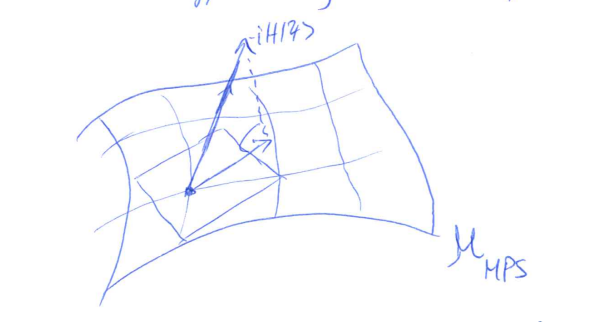

## 10.4 Generalizations and variational Monte Carlo

* **Tensor network states in higher dimensions & limitations**
* **Multiscale-entanglement-renormalization-ansatz (MERA)**
* **Neural quantum states (NQS) and variational Monte Carlo (VMC)**

## Added note on Variational Monte Carlo: Derivation of energy gradients

$$E(\theta) = \frac{\langle\psi_\theta|H|\psi_\theta\rangle}{\langle\psi_\theta|\psi_\theta\rangle} = \frac{\sum_{s, s'} \psi_s^* H_{s s'} \psi_{s'}}{\sum_s \psi_s^* \psi_s}$$

Using the quotient rule to compute the gradient with respect to parameter $\theta_k$:

$$\frac{\partial E_\theta}{\partial \theta_k} = \frac{1}{\langle\psi_\theta|\psi_\theta\rangle} \left[ \sum_{s, s'} \frac{\partial \psi_s^*}{\partial \theta_k} H_{s s'} \psi_{s'} + \underbrace{\sum_{s, s'} \psi_s^* H_{s s'} \frac{\partial \psi_{s'}}{\partial \theta_k}}_{H \text{ term } \rightarrow \text{ c.c. of 1st term}} \right] \quad \text{(differentiate numerator)}$$

$$- \frac{\langle\psi_\theta|H|\psi_\theta\rangle}{\langle\psi_\theta|\psi_\theta\rangle^2} \left[ \sum_s \frac{\partial \psi_s^*}{\partial \theta_k} \psi_s + \underbrace{\sum_s \psi_s^* \frac{\partial \psi_s}{\partial \theta_k}}_{\text{c.c. of 1st term}} \right] \quad \text{(differentiate denominator)}$$